In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV,GroupKFold
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor

In [5]:
df=pd.DataFrame(pd.read_csv(r'C:\Users\Tharun R Gowda\Desktop\Github project\rocket_pred\train_FD004.txt',sep='\s+',header=None))
df.shape
df

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61243,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,...,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.00,29.11,17.5234
61244,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,...,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.00,39.38,23.7151
61245,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,...,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.00,39.78,23.8270
61246,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,...,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.00,15.26,9.0774


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61248 entries, 0 to 61247
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       61248 non-null  int64  
 1   1       61248 non-null  int64  
 2   2       61248 non-null  float64
 3   3       61248 non-null  float64
 4   4       61248 non-null  float64
 5   5       61248 non-null  float64
 6   6       61248 non-null  float64
 7   7       61248 non-null  float64
 8   8       61248 non-null  float64
 9   9       61248 non-null  float64
 10  10      61248 non-null  float64
 11  11      61248 non-null  float64
 12  12      61248 non-null  float64
 13  13      61248 non-null  float64
 14  14      61248 non-null  float64
 15  15      61248 non-null  float64
 16  16      61248 non-null  float64
 17  17      61248 non-null  float64
 18  18      61248 non-null  float64
 19  19      61248 non-null  float64
 20  20      61248 non-null  float64
 21  21      61248 non-null  int64  
 22

In [3]:
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [8]:
cols=['unit number','time in cycles','operational setting 1','operational setting 2','operational setting 3']+[f'sensor measurement{i}' for i in range(1,22)]
df.columns=cols

In [9]:
df.head(15)

,unit number,time in cycles,operational setting 1,operational setting 2,operational setting 3,sensor measurement1,sensor measurement2,sensor measurement3,sensor measurement4,sensor measurement5,...,sensor measurement12,sensor measurement13,sensor measurement14,sensor measurement15,sensor measurement16,sensor measurement17,sensor measurement18,sensor measurement19,sensor measurement20,sensor measurement21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754
5,1,6,34.9996,0.8400,100.0,449.44,554.77,1352.87,1117.01,5.48,...,181.90,2387.87,8054.10,9.3346,0.02,330,2223,100.00,14.91,8.9057
6,1,7,0.0019,0.0001,100.0,518.67,641.83,1583.47,1393.89,14.62,...,520.48,2387.89,8127.92,8.3960,0.03,391,2388,100.00,38.93,23.4578
7,1,8,41.9981,0.8400,100.0,445.00,549.05,1344.16,1110.77,3.91,...,129.65,2387.97,8075.99,9.3679,0.02,329,2212,100.00,10.55,6.2787
8,1,9,42.0016,0.8400,100.0,445.00,549.55,1342.85,1101.67,3.91,...,129.65,2388.00,8071.13,9.3384,0.02,328,2212,100.00,10.63,6.3055
9,1,10,25.0019,0.6217,60.0,462.54,536.35,1251.91,1041.37,7.05,...,164.08,2028.13,7869.41,10.9141,0.02,305,1915,84.93,14.34,8.6119


In [ ]:
df.info()

In [7]:
df['max_values']=df.groupby('unit number')['time in cycles'].transform('max')

In [8]:
df['RUL']=df['max_values']-df['time in cycles']

In [9]:
df.drop(columns=('max_values'),inplace=True)

In [ ]:
df

In [10]:
drop_sensors = ['sensor measurement1', 'sensor measurement5', 'sensor measurement16', 'sensor measurement18', 'sensor measurement19']
df.drop(columns=drop_sensors,axis=1,inplace=True)

In [ ]:
df.corr()

In [ ]:
plt.figure(figsize=(20,20))
plt.scatter(x=df['RUL'], y=df['sensor measurement10'], color='red')
plt.xlabel('RUL')
plt.ylabel('sensor measurement1')
plt.show()

In [ ]:
# The Corrected Block
ewma_col = [col for col in df.columns if 'sensor measurement' in col]

# Note the [ ] around the two parts, and the .add_suffix()
df_final = pd.concat([df, df.groupby('unit number')[ewma_col].transform(lambda x: x.ewm(span=10).mean()).add_suffix('_ewm')], axis=1)

print(df_final.shape)
print(df_final.columns)

(61248, 38)
Index(['unit number', 'time in cycles', 'operational setting 1',
       'operational setting 2', 'operational setting 3', 'sensor measurement2',
       'sensor measurement3', 'sensor measurement4', 'sensor measurement6',
       'sensor measurement7', 'sensor measurement8', 'sensor measurement9',
       'sensor measurement10', 'sensor measurement11', 'sensor measurement12',
       'sensor measurement13', 'sensor measurement14', 'sensor measurement15',
       'sensor measurement17', 'sensor measurement20', 'sensor measurement21',
       'RUL', 'sensor measurement2_ewm', 'sensor measurement3_ewm',
       'sensor measurement4_ewm', 'sensor measurement6_ewm',
       'sensor measurement7_ewm', 'sensor measurement8_ewm',
       'sensor measurement9_ewm', 'sensor measurement10_ewm',
       'sensor measurement11_ewm', 'sensor measurement12_ewm',
       'sensor measurement13_ewm', 'sensor measurement14_ewm',
       'sensor measurement15_ewm', 'sensor measurement17_ewm',
       'senso

In [12]:
X=df_final.drop(columns='RUL',axis=1)
Y=df_final['RUL']

In [ ]:
df_final.head(10)

In [13]:

# .isin is actually vectorisation so we don't need loop 
units=df_final['unit number'].unique()
train_split = int(len(units) * 0.8)
train_units = units[:train_split]
val_units = units[train_split:]
train_df = df_final[df_final['unit number'].isin(train_units)]
val_df = df_final[df_final['unit number'].isin(val_units)]

In [ ]:

drop_cols = ['unit number', 'time in cycles', 'RUL'] 

X_train = train_df.drop(columns=drop_cols)
Y_train = train_df['RUL']

X_val = val_df.drop(columns=drop_cols)
Y_val = val_df['RUL']

Y_train_clipped = Y_train.clip(upper=100)
Y_val_clipped = Y_val.clip(upper=100)

print(f"Features: {X_train.shape[1]}")

Features: 35


In [ ]:
print(X_train)

In [ ]:
xgb=Pipeline(
    [
        ('model1',XGBRegressor(n_jobs=-1,random_state=42,device='cuda',tree_method='hist')),
    ]
)
lgbm=Pipeline(
    [
        ('model2',LGBMRegressor(random_state=42)),
    ]
)
cat=Pipeline(
    [
        ('model3',CatBoostRegressor(random_seed=42,task_type='GPU')),
    ]
)
params1={
    'model1__n_estimators': [300, 500, 700, 1000],
    'model1__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model1__max_depth': [3, 4, 5, 6, 7],                 
    'model1__min_child_weight': [1, 3, 5, 7],             # Regularization: Higher = Conservative
    'model1__gamma': [0, 0.1, 0.3, 0.5],                  # Regularization: Minimum loss reduction
    'model1__subsample': [0.6, 0.7, 0.8, 0.9],            # Use % of rows per tree
    'model1__colsample_bytree': [0.6, 0.7, 0.8, 0.9],     # Use % of columns per tree
    'model1__reg_alpha': [0, 0.01, 0.1, 1],               # L1 Regularization (Lasso)
    'model1__reg_lambda': [1, 1.5, 2, 3]                  # L2 Regularization (Ridge)
}
params2={
    'model2__n_estimators': [300, 500, 700, 1000],
    'model2__learning_rate': [0.01, 0.03, 0.05, 0.1],
    
    # CRITICAL: num_leaves controls complexity. 
    # 31 is standard (2^5 - 1), but we try smaller/larger for diversity.
    'model2__num_leaves': [20, 31, 50, 70], 
    'model2__max_depth': [-1, 5, 7, 10],            # -1 means no limit (let num_leaves decide)
    
    'model2__min_child_samples': [20, 30, 50, 100], # Prevents overfitting on noisy sensors
    'model2__subsample': [0.6, 0.7, 0.8, 0.9],      # Row sampling
    'model2__colsample_bytree': [0.6, 0.7, 0.8, 0.9], # Feature sampling
    'model2__reg_alpha': [0, 0.1, 0.5, 1],          # L1 Regularization
    'model2__reg_lambda': [0, 0.1, 0.5, 1]
}
params3={
    'model3__iterations': [500, 700, 1000],          # Number of trees
    'model3__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model3__depth': [4, 6, 8, 10],                  # Depth of the symmetric tree
    'model3__l2_leaf_reg': [1, 3, 5, 7, 9],          # L2 Regularization (Higher = smoother)
    
    # Unique to CatBoost:
    'model3__border_count': [32, 64, 128, 254],      # Quantization (How many bins for numeric features)
    'model3__bagging_temperature': [0, 0.5, 1],      # Bayesian Bootstrap controls variance
    'model3__random_strength': [1, 2, 5, 10]
}



In [ ]:
# 4. Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params1,
    n_iter=50,                              
    scoring='neg_root_mean_squared_error',  
    cv=GroupKFold(n_splits=3),                                 
    verbose=1,
    random_state=42,
    n_jobs=4
)


#turns to numpy array 
train_groups = train_df['unit number'].to_numpy()

random_search.fit(
    X_train, 
    Y_train_clipped,
    #This tells the random_search that to which cycle and unit number does the engine belongs as GroupKfold splits based on the engines like from 1 to 200 train data and 200 to 249 val data so it prevents data leakage as these engines in val data will not be shown to the model during training
    groups=train_groups       
)

print(f"Best RMSE: {-random_search.best_score_:.4f}")
print(f"Best Params: {random_search.best_params_}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best RMSE: 12.8712
Best Params: {'model1__subsample': 0.7, 'model1__reg_lambda': 3, 'model1__reg_alpha': 1, 'model1__n_estimators': 700, 'model1__min_child_weight': 1, 'model1__max_depth': 7, 'model1__learning_rate': 0.01, 'model1__gamma': 0.5, 'model1__colsample_bytree': 0.6}


In [ ]:
# 4. Setup RandomizedSearchCV
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=params2,
    n_iter=50,                              
    scoring='neg_root_mean_squared_error',
    cv=GroupKFold(n_splits=3),                                 
    verbose=1,
    random_state=42,
    n_jobs=3
)

print("Starting LightGBM Hyperparameter Tuning...")

# Extract groups for safety
train_groups = train_df['unit number'].to_numpy()

random_search_lgbm.fit(
    X_train, 
    Y_train_clipped,          
    groups=train_groups       
)

print(f"Best RMSE: {-random_search_lgbm.best_score_:.4f}")
print(f"Best Params: {random_search_lgbm.best_params_}")

Starting LightGBM Hyperparameter Tuning...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005862 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7868
[LightGBM] [Info] Number of data points in the train set: 49072, number of used features: 35
[LightGBM] [Info] Start training from score 79.520908
Best RMSE: 12.8266
Best Params: {'model2__subsample': 0.9, 'model2__reg_lambda': 0.5, 'model2__reg_alpha': 1, 'model2__num_leaves': 50, 'model2__n_estimators': 700, 'model2__min_child_samples': 50, 'model2__max_depth': -1, 'model2__learning_rate': 0.01, 'model2__colsample_bytree': 0.6}


In [ ]:
# 4. Setup RandomizedSearchCV
random_search_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=params3,
    n_iter=20,                              
    scoring='neg_root_mean_squared_error',
    cv=GroupKFold(n_splits=3),                                 
    verbose=1,
    random_state=42,
    n_jobs=4
)


# Extract groups
train_groups = train_df['unit number'].to_numpy()

random_search_cat.fit(
    X_train, 
    Y_train_clipped,          # Use CLIPPED target
    groups=train_groups       # Pass groups
)

print(f"Best RMSE: {-random_search_cat.best_score_:.4f}")
print(f"Best Params: {random_search_cat.best_params_}")

In [29]:
gkf = GroupKFold(n_splits=5)
# Create a static list of indices so the Stacker can't mess it up
cv_splits = list(gkf.split(X_train, Y_train_clipped, groups=train_df['unit number'].to_numpy()))

estimator=[
    ('xgb',XGBRegressor(subsample= 0.7, reg_lambda= 3, reg_alpha= 1, n_estimators= 700, min_child_weight= 1, max_depth= 7, learning_rate= 0.01, gamma= 0.5, colsample_bytree= 0.6,n_jobs=-1,random_state=42,device='cuda',tree_method='hist')),
    ('lgmb',LGBMRegressor(subsample= 0.9, reg_lambda= 0.5, reg_alpha= 1, num_leaves= 50, n_estimators= 700, min_child_samples= 50, max_depth=-1, learning_rate= 0.01, colsample_bytree=0.6,verbose=-1)),
    ('cat', CatBoostRegressor(iterations=2000, learning_rate=0.02, depth=6, l2_leaf_reg=5, border_count=128, loss_function='RMSE', random_seed=42, verbose=0, allow_writing_files=False, task_type="GPU"))
]

stack=StackingRegressor(
    estimators=estimator,
    final_estimator=Ridge(),
    cv=cv_splits,            
    n_jobs=1
)

stack.fit(X_train,Y_train_clipped)
y_pred1=stack.predict(X_val)
print(r2_score(Y_val_clipped,y_pred1))

c:\Users\Tharun R Gowda\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:774: UserWarning: [19:56:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


0.8624795969704686


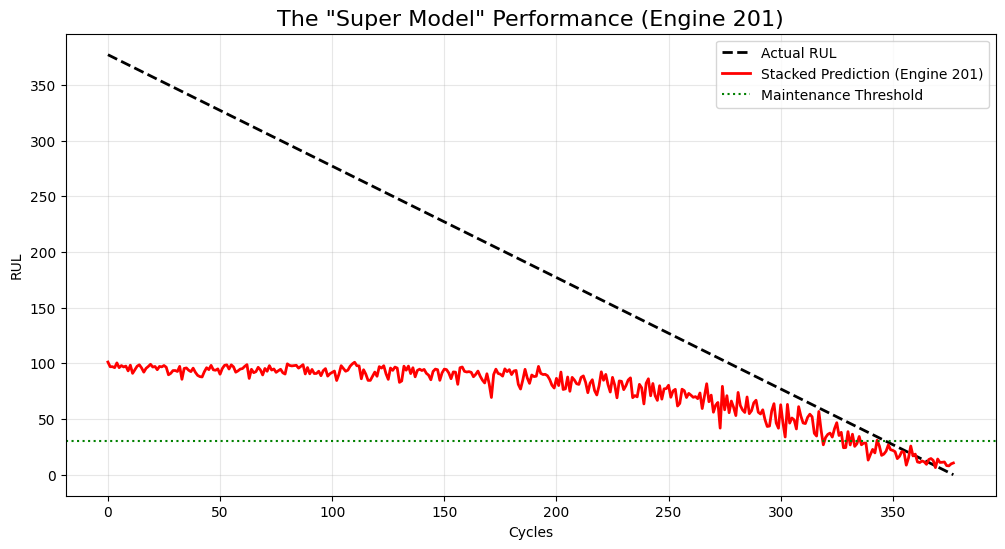

In [45]:
import matplotlib.pyplot as plt

# 1. Pick the Engine ID first
unique_validation_engines = val_df['unit number'].unique()
test_engine_id = unique_validation_engines[1]  # This is just the number (e.g., 2)

# 2. Create the Mask (True/False list)
mask = val_df['unit number'] == test_engine_id

# 3. Apply the Mask to get the data
X_test_engine = X_val[mask]
y_test_engine_true = val_df.loc[mask, 'RUL']

# 4. Predict using the STACK
y_test_engine_pred = stack.predict(X_test_engine)

# 5. Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_engine_true.values, label='Actual RUL', color='black', linestyle='--', linewidth=2)
plt.plot(y_test_engine_pred, label=f'Stacked Prediction (Engine {test_engine_id})', color='red', linewidth=2)
plt.axhline(y=30, color='green', linestyle=':', label='Maintenance Threshold')

plt.title(f'The "Super Model" Performance (Engine {test_engine_id})', fontsize=16)
plt.ylabel('RUL')
plt.xlabel('Cycles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.metrics import mean_squared_error, r2_score
# import matplotlib.pyplot as plt

# # 1. Load the Test Data and Truth Data
# # (Adjust paths if necessary)
# test_df = pd.read_csv('test_FD004.txt', sep='\s+', header=None, 
#                       names=['unit_number', 'time', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)])
# true_rul = pd.read_csv(r'C:\Users\Tharun R Gowda\Desktop\Github project\rocket_pred\test_FD004.txt', sep='\s+', header=None, names=['RUL'])

# # 2. Process Test Data (We only need the LAST row of each engine)
# # The model needs the most recent sensor reading to make a prediction.
# X_test_final = []
# test_ids = test_df['unit_number'].unique()

# for unit in test_ids:
#     # Get the data for this engine
#     unit_data = test_df[test_df['unit_number'] == unit]
    
#     # Grab just the LAST row (the "cut-off" point)
#     last_row = unit_data.iloc[-1]
#     X_test_final.append(last_row)

# # Convert to DataFrame
# X_test_final = pd.DataFrame(X_test_final)

# # 3. CRITICAL: Apply the SAME Feature Engineering!
# # (We must drop the same columns you dropped in Training)
# # Update this list if you dropped different columns!
# cols_to_drop = ['unit_number', 'time', 'ope3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']
# X_test_ready = X_test_final.drop(columns=cols_to_drop, errors='ignore')

# # 4. Make Predictions
# print(f"Predicting on {len(X_test_ready)} Test Engines...")
# y_pred_test = stack.predict(X_test_ready)

# # 5. Clip the Truth (Just like we did for Training)
# # We can't expect the model to predict > 125 if we trained it to clip at 125.
# y_true_clipped = true_rul['RUL'].clip(upper=125)

# # 6. Final Score
# final_rmse = np.sqrt(mean_squared_error(y_true_clipped, y_pred_test))
# final_r2 = r2_score(y_true_clipped, y_pred_test)

# print("="*30)
# print("FINAL TEST RESULTS (Official FD004)")
# print("="*30)
# print(f"RMSE: {final_rmse:.2f}")
# print(f"R2 Score: {final_r2:.4f}")
# print("="*30)

# # 7. Plot the Results
# plt.figure(figsize=(10, 5))
# plt.plot(y_true_clipped, label='Actual RUL (Clipped)', color='black')
# plt.plot(y_pred_test, label='Model Prediction', color='red', alpha=0.7)
# plt.title('Final Test: Predictions vs True RUL')
# plt.legend()
# plt.show()

Predicting on 248 Test Engines...


ValueError: feature_names mismatch: ['operational setting 1', 'operational setting 2', 'operational setting 3', 'sensor measurement2', 'sensor measurement3', 'sensor measurement4', 'sensor measurement6', 'sensor measurement7', 'sensor measurement8', 'sensor measurement9', 'sensor measurement10', 'sensor measurement11', 'sensor measurement12', 'sensor measurement13', 'sensor measurement14', 'sensor measurement15', 'sensor measurement17', 'sensor measurement20', 'sensor measurement21', 'sensor measurement2_ewm', 'sensor measurement3_ewm', 'sensor measurement4_ewm', 'sensor measurement6_ewm', 'sensor measurement7_ewm', 'sensor measurement8_ewm', 'sensor measurement9_ewm', 'sensor measurement10_ewm', 'sensor measurement11_ewm', 'sensor measurement12_ewm', 'sensor measurement13_ewm', 'sensor measurement14_ewm', 'sensor measurement15_ewm', 'sensor measurement17_ewm', 'sensor measurement20_ewm', 'sensor measurement21_ewm'] ['os1', 'os2', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13'